In [13]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
ART = Path("artifacts"); (ART / "models").mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

In [14]:
##1.concentration of metals

In [15]:
METALS  = ["Zn", "Cd", "Pb", "Cu", "Ni", "Mn", "As", "Cr"]
TARGETS = ["HPI", "HEI", "DC"]
CATS    = ["Site", "Month"]          # Month = season (winter/spring/summer/autumn)

# --- concentrations ---------------------------------------------------------
conc = pd.read_excel("Heavy_Metal_Concentrations.xlsx", header=1)
conc.columns = [str(c).strip() for c in conc.columns]
conc = conc[["Site", "Year", "Month"] + METALS].dropna(how="all")
conc[METALS] = conc[METALS].apply(pd.to_numeric)
conc["Year"] = conc["Year"].astype(int)

# --- indices (two header rows) ---------------------------------------------
raw = pd.read_excel("Pollution_Indices.xls", header=None, engine="xlrd")
second_header = raw.iloc[1].astype(str).str.strip()
idx = raw.iloc[2:].reset_index(drop=True)
idx.columns = second_header
idx = idx.loc[:, ~idx.columns.duplicated(keep="first") | idx.columns.isin(TARGETS)]  # HPI/HEI/DC are unique labels
idx = idx[["Site", "Year", "Month"] + TARGETS].copy()
idx["Year"] = idx["Year"].astype(int)
idx[TARGETS] = idx[TARGETS].apply(pd.to_numeric)

df = conc.merge(idx, on=["Site", "Year", "Month"], how="inner", validate="one_to_one")
print("concentrations:", conc.shape, "| indices:", idx.shape, "| merged:", df.shape)
assert len(df) == len(conc) == len(idx), "rows lost in the merge"
df.head()

concentrations: (40, 11) | indices: (40, 6) | merged: (40, 14)


,Site,Year,Month,Zn,Cd,Pb,Cu,Ni,Mn,As,Cr,HPI,HEI,DC
0,S1,2018,winter,5.40,1.0,1.0,6.3,3,5.3,5.0,1.0,0.731669,3.20308,-5.798
1,S1,2018,spring,4.80,1.0,1.2,5.4,3,4.7,5.0,1.0,0.723971,3.19296,-5.808
2,S1,2018,summer,5.90,1.0,1.0,4.8,3,1.0,5.0,1.0,0.732553,3.08718,-5.914
3,S1,2018,autumn,4.05,1.0,1.0,5.3,6,1.0,5.0,1.0,0.728864,3.24681,-5.754
4,S1,2019,winter,4.00,1.0,1.4,8.6,3,2.3,5.0,1.0,0.716515,3.22880,-5.772


In [16]:
print("Missing values:", int(df.isna().sum().sum()))
df[METALS + TARGETS].describe().T.round(4)

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
Zn,40.0,4.6418,1.1185,2.0300,4.0950,4.7750,5.2725,6.5600
Cd,40.0,1.0075,0.0267,1.0000,1.0000,1.0000,1.0000,1.1000
Pb,40.0,1.0325,0.0888,1.0000,1.0000,1.0000,1.0000,1.4000
Cu,40.0,6.3938,1.7681,4.2500,5.3375,6.0000,7.2625,12.0000
Ni,40.0,3.3000,0.6869,3.0000,3.0000,3.0000,3.0000,6.0000
Mn,40.0,4.0125,2.7387,1.0000,1.9750,3.3000,5.6000,11.3000
As,40.0,5.0575,0.2218,5.0000,5.0000,5.0000,5.0000,6.0000
Cr,40.0,1.0550,0.2207,1.0000,1.0000,1.0000,1.0000,2.0000
HPI,40.0,0.7294,0.0039,0.7165,0.7282,0.7313,0.7319,0.7330
HEI,40.0,3.2057,0.0654,3.0872,3.1588,3.1954,3.2510,3.3428


## 2. Quick look at the data
Cd, Cr, As and Pb are close to constant (many values sit at the detection limit), so Zn, Cu, Mn and Ni carry most of the variation.

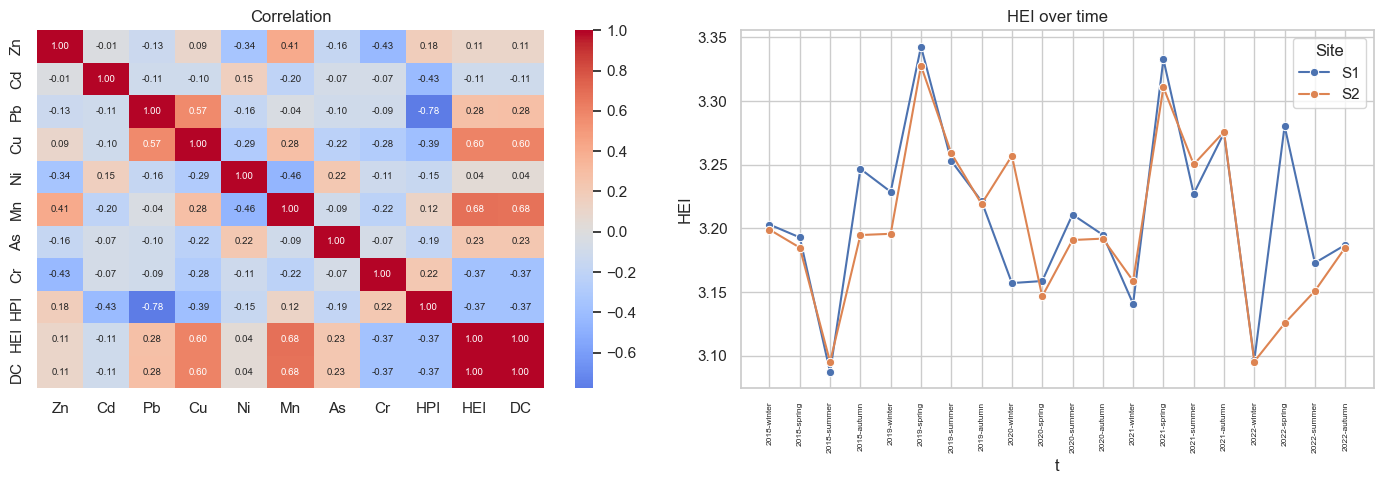

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[METALS + TARGETS].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Correlation")
for tgt, ax in zip(["HEI"], [axes[1]]):
    sns.lineplot(data=df.assign(t=df["Year"].astype(str) + "-" + df["Month"]), x="t", y=tgt, hue="Site", marker="o", ax=ax)
    ax.tick_params(axis="x", rotation=90, labelsize=6); ax.set_title("HEI over time")
plt.tight_layout(); plt.show()

## 3. Train / test split
Sites **S1 and S2 have almost identical values at the same date**, so a random split would leak information
(S1's row in the train set would "give away" S2's row in the test set).
Instead we hold out a **whole period**: all samples from **2022 → test (8 rows)**; 2018–2021 → train (32 rows).
Inside the training set, cross-validation is done **leave-one-year-out** for the same reason.

In [18]:
TEST_YEAR = 2022
train = df[df["Year"] != TEST_YEAR].reset_index(drop=True)
test  = df[df["Year"] == TEST_YEAR].reset_index(drop=True)
print("train:", train.shape, "| test:", test.shape)

FEATURES = METALS + CATS
train.to_csv(ART / "train.csv", index=False)
test.to_csv(ART / "test.csv", index=False)
json.dump({"METALS": METALS, "CATS": CATS, "TARGETS": TARGETS, "TEST_YEAR": TEST_YEAR,
           "RANDOM_STATE": RANDOM_STATE}, open(ART / "meta.json", "w"), indent=2)

train: (32, 14) | test: (8, 14)


## 4. Build the model pipelines
Every model = *standardise numeric metals + one-hot site/season* → *regressor*. The target is standardised internally too.
Four model families (linear, bagged trees, boosted trees, kernel):

In [19]:
def build_pipeline(model):
    """Preprocessing + model, with the target standardised (helps SVR/Ridge when the target has a tiny scale)."""
    pre = ColumnTransformer([
        ("num", StandardScaler(), METALS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATS),
    ])
    return TransformedTargetRegressor(
        regressor=Pipeline([("pre", pre), ("model", model)]),
        transformer=StandardScaler(),
    )

def get_models():
    return {
        "Ridge":            Ridge(),
        "RandomForest":     RandomForestRegressor(random_state=RANDOM_STATE),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "SVR":              SVR(),
    }

## 5. Train baseline models (default parameters)
Cross-validation on the training set (leave-one-year-out, 4 folds) gives an honest estimate **before** touching the test set.

In [20]:
cv = GroupKFold(n_splits=train["Year"].nunique())
groups = train["Year"]
scoring = {"RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error", "R2": "r2"}

rows = []
for target in TARGETS:
    X, y = train[FEATURES], train[target]
    for name, model in get_models().items():
        pipe = build_pipeline(model)
        res = cross_validate(pipe, X, y, cv=cv, groups=groups, scoring=scoring)
        rows.append({"target": target, "model": name,
                     "CV_RMSE": -res["test_RMSE"].mean(), "CV_MAE": -res["test_MAE"].mean(), "CV_R2": res["test_R2"].mean()})
        pipe.fit(X, y)                                            # final fit on the whole training set
        joblib.dump(pipe, ART / "models" / f"baseline_{target}_{name}.joblib")

baseline_cv = pd.DataFrame(rows)
baseline_cv.to_csv(ART / "baseline_cv.csv", index=False)
baseline_cv.round(5)

,target,model,CV_RMSE,CV_MAE,CV_R2
0,HPI,Ridge,0.00053,0.00040,0.96552
1,HPI,RandomForest,0.00223,0.00153,0.54822
2,HPI,GradientBoosting,0.00179,0.00121,0.71326
3,HPI,SVR,0.00270,0.00191,0.45642
4,HEI,Ridge,0.01300,0.01063,0.85050
5,HEI,RandomForest,0.06076,0.05282,-0.81087
6,HEI,GradientBoosting,0.06658,0.05796,-1.36103
7,HEI,SVR,0.04336,0.03342,0.23344
8,DC,Ridge,0.01298,0.01062,0.85026
9,DC,RandomForest,0.06137,0.05388,-0.82288


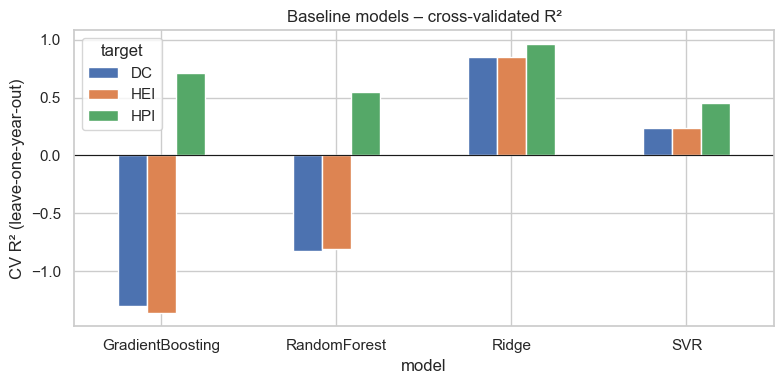

In [21]:
pivot = baseline_cv.pivot(index="model", columns="target", values="CV_R2")
ax = pivot.plot.bar(figsize=(8, 4)); ax.set_ylabel("CV R² (leave-one-year-out)"); ax.axhline(0, color="k", lw=.8)
ax.set_title("Baseline models – cross-validated R²"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()